# IMAGE SEGMENTATION WITH FUZZY C-MEANS

## 0. Import thư viện & đọc ảnh

In [18]:
%matplotlib inline

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import skfuzzy as fuzz

Kích thước sau resize: 600x300 (180000 pixel)


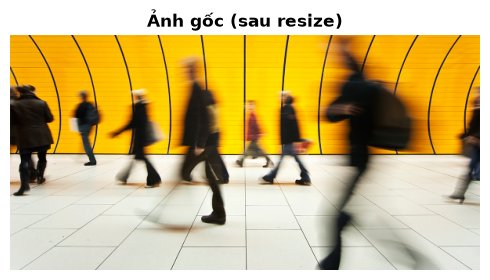

In [19]:
IMG_PATH       = "../../data/images/walking.jpg"   
SCALE_PERCENT  = 50                                    # resize

def load_and_resize(path, scale_percent=50):
    bgr_img = cv2.imread(path)
    if bgr_img is None:
        raise FileNotFoundError(f"Không tìm thấy ảnh: {path}")
    rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    new_w = int(rgb_img.shape[1] * scale_percent / 100)
    new_h = int(rgb_img.shape[0] * scale_percent / 100)
    resized = cv2.resize(rgb_img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized

resized_img = load_and_resize(IMG_PATH, SCALE_PERCENT)
h, w, c = resized_img.shape
pixels = resized_img.reshape((-1, 3)).astype(np.float64)
print(f"Kích thước sau resize: {w}x{h} ({pixels.shape[0]} pixel)")

plt.figure(figsize=(5, 4))
plt.imshow(resized_img)
plt.title("Ảnh gốc (sau resize)", fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

## FCM

In [20]:
def fast_fcm_image(pixels, n_clusters=4, m=2.0, max_iter=30, tol=1e-3, random_state=42):
    np.random.seed(random_state)
    n_samples = pixels.shape[0]
    U = np.random.dirichlet(np.ones(n_clusters), size=n_samples).astype(np.float64)

    for iteration in range(max_iter):
        um = U ** m
        centroids = (um.T @ pixels) / (np.sum(um, axis=0)[:, np.newaxis] + 1e-8)

        dists = np.zeros((n_samples, n_clusters))
        for j in range(n_clusters):
            dists[:, j] = np.linalg.norm(pixels - centroids[j], axis=1)
        dists = np.fmax(dists, 1e-8)

        power = 2.0 / (m - 1.0)
        U_new = np.zeros((n_samples, n_clusters))
        for j in range(n_clusters):
            ratio = dists[:, [j]] / dists
            U_new[:, j] = 1.0 / np.sum(ratio ** power, axis=1)

        diff = np.linalg.norm(U_new - U)
        U = U_new
        if diff < tol:
            break

    labels = np.argmax(U, axis=1)
    max_u  = np.max(U, axis=1)
    return centroids, labels, max_u, U

print("FCM implementation done.")

FCM implementation done.


## Phân đoạn ảnh với nhiều giá trị k

 Áp dụng FCM với `k in {2, 3, 4, 5}` và hiển thị ảnh phân đoạn tương ứng.

In [21]:
k_list = [2, 3, 4, 5]
fcm_results    = {}
fcm_confidence = {}
fcm_centroids  = {}
fcm_labels     = {}

for k in k_list:
    print(f"Run FCM với k = {k}...")
    centroids, labels, max_u, _ = fast_fcm_image(pixels, n_clusters=k, m=2, max_iter=30)
    centers_uint8 = np.round(np.clip(centroids, 0, 255)).astype(np.uint8) 
    fcm_results[k]    = centers_uint8[labels].reshape(h, w, 3)
    fcm_confidence[k] = max_u.reshape(h, w)
    fcm_centroids[k]  = centroids
    fcm_labels[k]     = labels

Run FCM với k = 2...
Run FCM với k = 3...
Run FCM với k = 4...
Run FCM với k = 5...


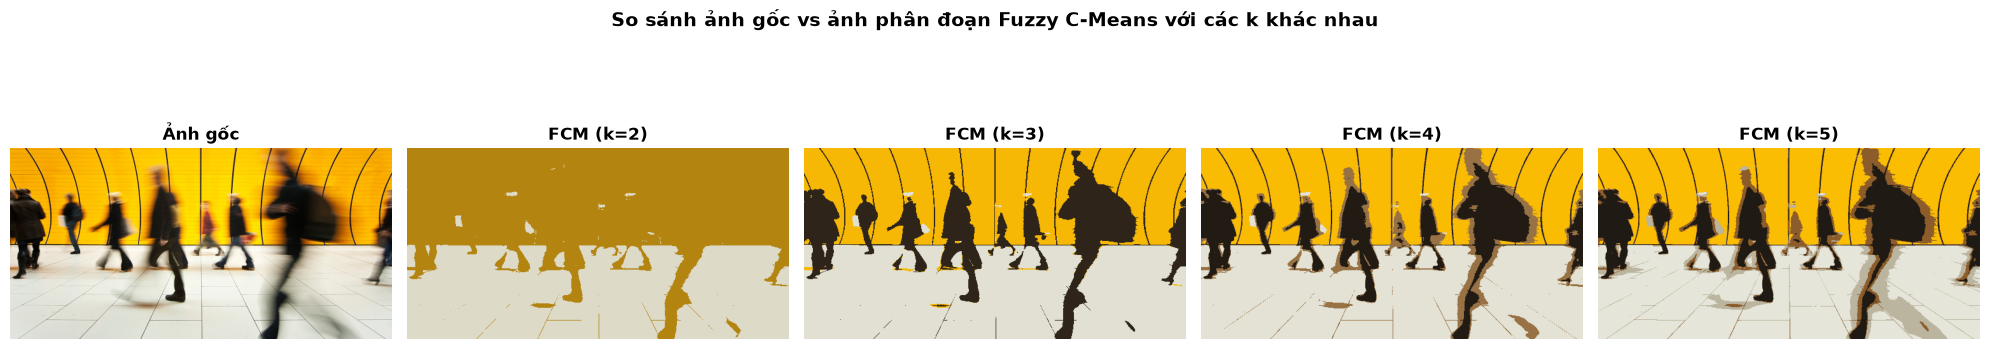

In [22]:
fig, axes = plt.subplots(1, len(k_list) + 1, figsize=(4 * (len(k_list) + 1), 4.5))

axes[0].imshow(resized_img)
axes[0].set_title("Ảnh gốc", fontweight="bold")
axes[0].axis("off")

for i, k in enumerate(k_list):
    axes[i + 1].imshow(fcm_results[k])
    axes[i + 1].set_title(f"FCM (k={k})", fontweight="bold")
    axes[i + 1].axis("off")

plt.suptitle("So sánh ảnh gốc vs ảnh phân đoạn Fuzzy C-Means với các k khác nhau",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## FCM vs Thư viện scikit-fuzzy

So sánh `fast_fcm_image` voi `skfuzzy.cluster.cmeans` - **cùng thuật toán FCM** 

In [23]:
def fcm_skfuzzy(pixels, n_clusters=4, m=2.0, error=0.005, maxiter=1000, seed=42):
    """Wrapper cho skfuzzy.cluster.cmeans."""
    np.random.seed(seed)
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        pixels.T, n_clusters, m, error=error, maxiter=maxiter, init=None
    )
    labels = np.argmax(u, axis=0)
    return cntr, labels, u.T


def match_labels(centroids_a, labels_a, centroids_b):
    cost = np.linalg.norm(centroids_a[:, None, :] - centroids_b[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost)
    remap = dict(zip(row_ind, col_ind))
    return np.vectorize(remap.get)(labels_a)

In [24]:
K_COMPARE = 4

print(f"Run FCM thư viện scikit-fuzzy (k={K_COMPARE})...")
lib_centroids, lib_labels_raw, lib_u = fcm_skfuzzy(pixels, n_clusters=K_COMPARE, m=2.0)

custom_centroids = fcm_centroids[K_COMPARE]
custom_labels_raw = fcm_labels[K_COMPARE]

lib_labels = match_labels(lib_centroids, lib_labels_raw, custom_centroids)
agreement = np.mean(lib_labels == custom_labels_raw) * 100

print(f"Tỉ lệ pixel cùng nhãn cụm (sau Hungarian matching): {agreement:.2f}%")

Run FCM thư viện scikit-fuzzy (k=4)...
Tỉ lệ pixel cùng nhãn cụm (sau Hungarian matching): 99.98%


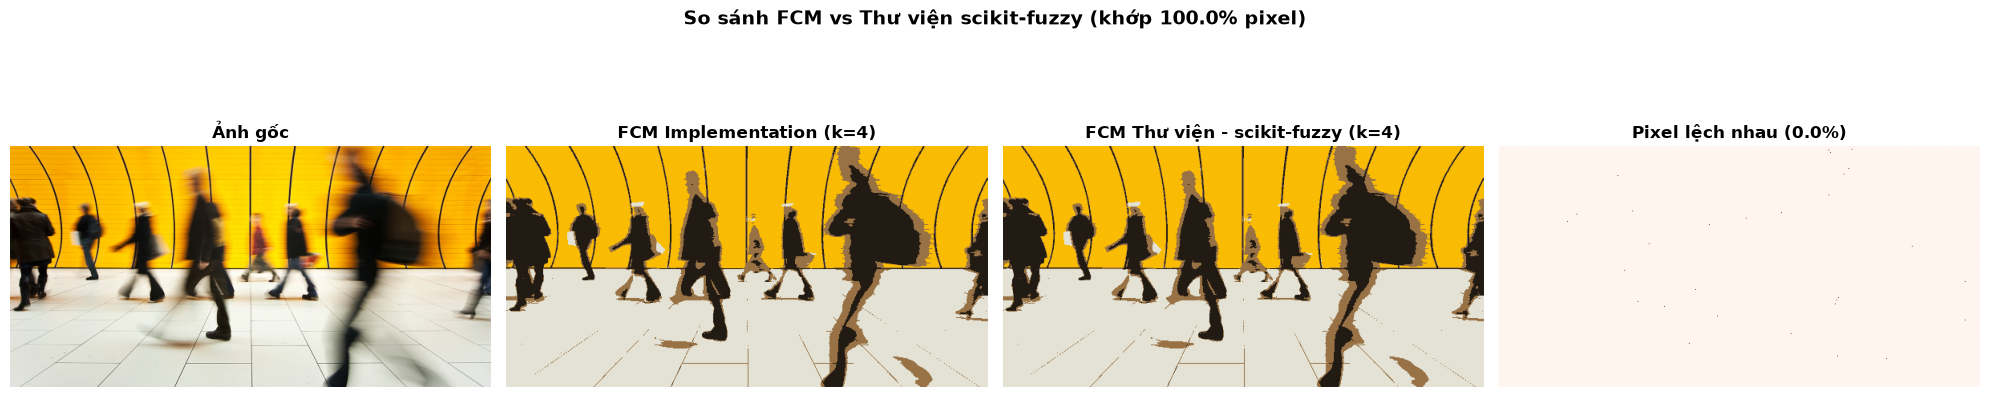

In [25]:
custom_segmented = fcm_results[K_COMPARE]
lib_centers_uint8 = np.round(np.clip(lib_centroids, 0, 255)).astype(np.uint8)
lib_segmented     = lib_centers_uint8[lib_labels_raw].reshape(h, w, 3)
mismatch_map      = (lib_labels != custom_labels_raw).reshape(h, w)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(resized_img)
axes[0].set_title("Ảnh gốc", fontweight="bold")

axes[1].imshow(custom_segmented)
axes[1].set_title(f"FCM Implementation (k={K_COMPARE})", fontweight="bold")

axes[2].imshow(lib_segmented)
axes[2].set_title(f"FCM Thư viện - scikit-fuzzy (k={K_COMPARE})", fontweight="bold")

axes[3].imshow(mismatch_map, cmap="Reds")
axes[3].set_title(f"Pixel lệch nhau ({100 - agreement:.1f}%)", fontweight="bold")

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"So sánh FCM vs Thư viện scikit-fuzzy (khớp {agreement:.1f}% pixel)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

**Nhận xét:**
- FCM nhạy cảm với khởi tạo ban đầu hơn K-Means, nên tỉ lệ khớp thường thấp hơn một chút.
- Tỷ lệ khớp cao cho thấy implementation tự viết hoạt động tương đồng với thư viện `scikit-fuzzy`.